# **Part 1: CNN**
# **Assignment 03: Convolutional Neural Networks**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Установить случайное начальное значение (seed) для воспроизводимости результатов
np.random.seed(0)

print("Libraries loaded successfully.")

Libraries loaded successfully.


### P1.1 Input Image
Черно-белое изображение — это матрица 6×6. Каждое значение представляет интенсивность пикселя (диапазон 0–255, здесь используются маленькие целые числа)

Input Image (6x6):
[[1. 2. 0. 3. 1. 2.]
 [2. 1. 1. 0. 2. 3.]
 [0. 1. 2. 3. 1. 0.]
 [3. 0. 1. 2. 2. 1.]
 [2. 1. 0. 1. 3. 0.]
 [1. 0. 2. 1. 0. 2.]]

Shape: (6, 6)


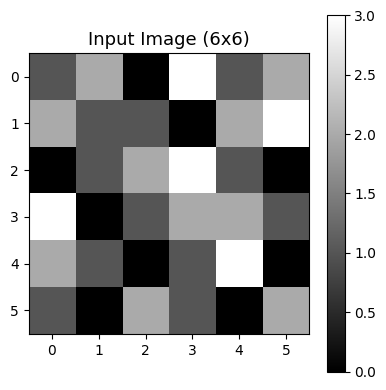

In [2]:

# Определите (задайте) входное изображение в оттенках серого размером 6×6.
image = np.array([
    [1, 2, 0, 3, 1, 2],
    [2, 1, 1, 0, 2, 3],
    [0, 1, 2, 3, 1, 0],
    [3, 0, 1, 2, 2, 1],
    [2, 1, 0, 1, 3, 0],
    [1, 0, 2, 1, 0, 2]
], dtype=np.float32)

print("Input Image (6x6):")
print(image)
print(f"\nShape: {image.shape}")

# Visualize the input image
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.colorbar()
plt.title('Input Image (6x6)', fontsize=13)
plt.tight_layout()
plt.savefig('p1_input_image.png', dpi=100, bbox_inches='tight')
plt.show()

## P1.2 Spatial Dimension Calculation

Формула для вычисления размера выхода сверточного слоя или слоя пулинга:

$$\text{Output Size} = \left\lfloor \frac{N - F + 2P}{S} \right\rfloor + 1$$

Where:
- **N** = Input spatial size(размер входного изображения)
- **F** = Filter (kernel) size(размер фильтра (ядра))
- **P** = Padding(дополнение)
- **S** = Stride(шаг)

### Conv Layer 1
- N = 6, F = 3, P = 0, S = 1
- Output = (6 - 3 + 0) / 1 + 1 = **4** → Output shape: **4×4**

### Max Pooling Layer
- N = 4, F = 2, P = 0, S = 2
- Output = (4 - 2 + 0) / 2 + 1 = **2** → Output shape: **2×2**

In [3]:

def output_size(N, F, P, S):
    """Calculate output spatial size using the standard formula."""
    return int((N - F + 2 * P) / S) + 1

# Conv Layer 1
N, F, P, S = 6, 3, 0, 1
out_conv = output_size(N, F, P, S)
print(f"Conv Layer 1:   N={N}, F={F}, P={P}, S={S}")
print(f"  Output size = ({N} - {F} + 2*{P}) / {S} + 1 = {out_conv}x{out_conv}")

# Max Pooling Layer
N2, F2, P2, S2 = out_conv, 2, 0, 2
out_pool = output_size(N2, F2, P2, S2)
print(f"\nMax Pooling:    N={N2}, F={F2}, P={P2}, S={S2}")
print(f"  Output size = ({N2} - {F2} + 2*{P2}) / {S2} + 1 = {out_pool}x{out_pool}")

print(f"\nSummary of Shapes:")
print(f"  Input            : 6x6")
print(f"  After Conv Layer : {out_conv}x{out_conv}")
print(f"  After MaxPool    : {out_pool}x{out_pool}")


Conv Layer 1:   N=6, F=3, P=0, S=1
  Output size = (6 - 3 + 2*0) / 1 + 1 = 4x4

Max Pooling:    N=4, F=2, P=0, S=2
  Output size = (4 - 2 + 2*0) / 2 + 1 = 2x2

Summary of Shapes:
  Input            : 6x6
  After Conv Layer : 4x4
  After MaxPool    : 2x2


## P1.3 Convolution Layer Forward Pass

Мы применяем 2 фильтра вручную. Каждый фильтр скользит по изображению 6×6 с шагом 1, без паддинга. На каждой позиции вычисляем сумму поэлементного умножения + смещение (bias) = 1.

**Filter 1** (detects vertical edges):
```
[[ 1,  0, -1],
 [ 1,  0, -1],
 [ 1,  0, -1]]
```

**Filter 2** (detects horizontal edges):
```
[[-1,  2, -1],
 [ 0,  0,  0],
 [-1,  2, -1]]
```

Feature Map 1 (Filter 1, before ReLU):
[[ 1. -1.  0.  2.]
 [ 2. -2.  0.  2.]
 [ 3. -3. -2.  6.]
 [ 4. -2. -1.  2.]]

Shape: (4, 4)

Feature Map 2 (Filter 2, before ReLU):
[[ 4. -4.  9. -3.]
 [-4.  2. -1.  3.]
 [ 1. -1.  3.  5.]
 [-6.  4.  2. -1.]]

Shape: (4, 4)


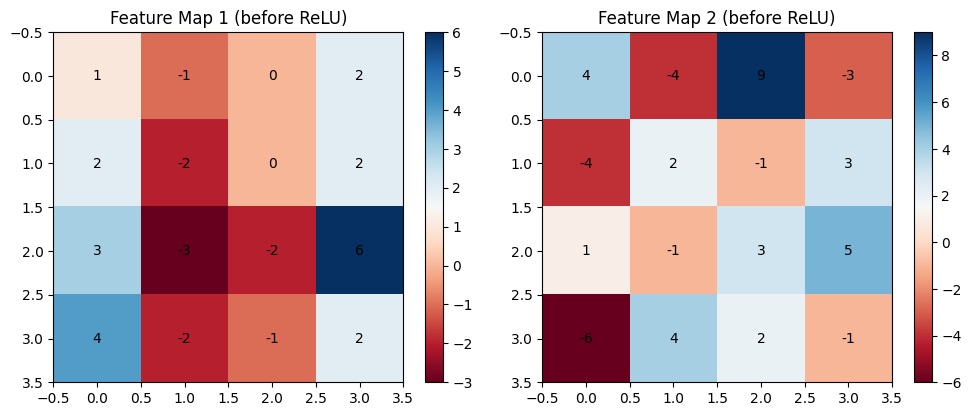

In [4]:
# Определите два фильтра размером 3×3
filter1 = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1]
], dtype=np.float32)

filter2 = np.array([
    [-1,  2, -1],
    [ 0,  0,  0],
    [-1,  2, -1]
], dtype=np.float32)

bias = 1.0  # Оба фильтра используют одинаковое смещение (bias) = 1

def manual_conv2d(image, kernel, bias, stride=1):
    """Perform 2D convolution (no padding) manually with NumPy."""
    N = image.shape[0]
    F = kernel.shape[0]
    out_size = (N - F) // stride + 1
    output = np.zeros((out_size, out_size), dtype=np.float32)
    for i in range(out_size):
        for j in range(out_size):
            patch = image[i*stride : i*stride+F, j*stride : j*stride+F]
            output[i, j] = np.sum(patch * kernel) + bias
    return output

# Вычислить карты признаков
feature_map1 = manual_conv2d(image, filter1, bias, stride=1)
feature_map2 = manual_conv2d(image, filter2, bias, stride=1)

print("Feature Map 1 (Filter 1, before ReLU):")
print(feature_map1)
print(f"\nShape: {feature_map1.shape}")

print("\nFeature Map 2 (Filter 2, before ReLU):")
print(feature_map2)
print(f"\nShape: {feature_map2.shape}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im1 = axes[0].imshow(feature_map1, cmap='RdBu', interpolation='nearest')
axes[0].set_title('Feature Map 1 (before ReLU)', fontsize=12)
plt.colorbar(im1, ax=axes[0])
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{feature_map1[i,j]:.0f}', ha='center', va='center', fontsize=10)

im2 = axes[1].imshow(feature_map2, cmap='RdBu', interpolation='nearest')
axes[1].set_title('Feature Map 2 (before ReLU)', fontsize=12)
plt.colorbar(im2, ax=axes[1])
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{feature_map2[i,j]:.0f}', ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('p1_feature_maps.png', dpi=100, bbox_inches='tight')
plt.show()

## P1.4 ReLU Activation

ReLU (Rectified Linear Unit) заменяет все отрицательные значения на 0:
$$\text{ReLU}(x) = \max(0, x)$$

Это вводит нелинейность в сеть и помогает модели изучать сложные шаблоны (паттерны).

After ReLU — Feature Map 1:
[[1. 0. 0. 2.]
 [2. 0. 0. 2.]
 [3. 0. 0. 6.]
 [4. 0. 0. 2.]]

After ReLU — Feature Map 2:
[[4. 0. 9. 0.]
 [0. 2. 0. 3.]
 [1. 0. 3. 5.]
 [0. 4. 2. 0.]]


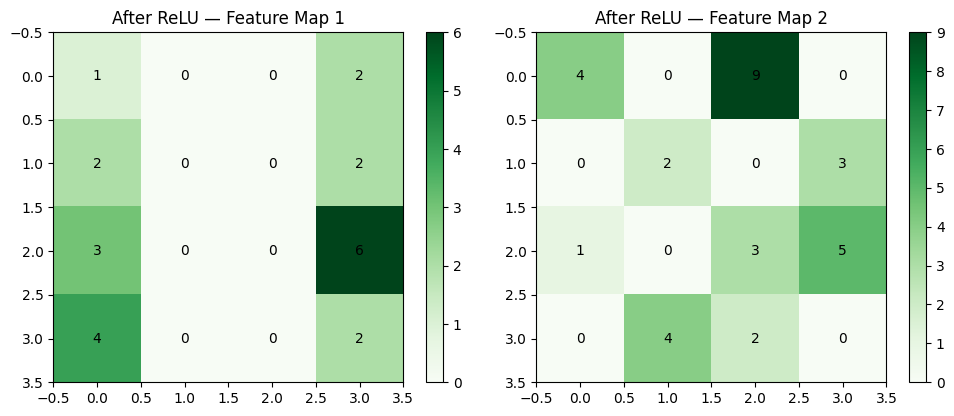

In [5]:
# Примените ReLU: замените отрицательные значения на 0
relu1 = np.maximum(0, feature_map1)
relu2 = np.maximum(0, feature_map2)

print("After ReLU — Feature Map 1:")
print(relu1)
print("\nAfter ReLU — Feature Map 2:")
print(relu2)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im1 = axes[0].imshow(relu1, cmap='Greens', interpolation='nearest')
axes[0].set_title('After ReLU — Feature Map 1', fontsize=12)
plt.colorbar(im1, ax=axes[0])
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{relu1[i,j]:.0f}', ha='center', va='center', fontsize=10)

im2 = axes[1].imshow(relu2, cmap='Greens', interpolation='nearest')
axes[1].set_title('After ReLU — Feature Map 2', fontsize=12)
plt.colorbar(im2, ax=axes[1])
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{relu2[i,j]:.0f}', ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('p1_relu.png', dpi=100, bbox_inches='tight')
plt.show()

## P1.5 Max Pooling Layer

Max Pooling выбирает максимальное значение из каждого неперекрывающегося окна 2×2 (stride=2).
Он уменьшает пространственные размеры, сохраняет самую сильную активацию и обеспечивает инвариантность к сдвигу.

Вход: 4×4 карта признаков

Размер окна: 2×2, шаг 2

Выход: 2×2 карта признаков

After Max Pooling — Feature Map 1 (2x2):
[[2. 2.]
 [4. 6.]]

After Max Pooling — Feature Map 2 (2x2):
[[4. 9.]
 [4. 5.]]


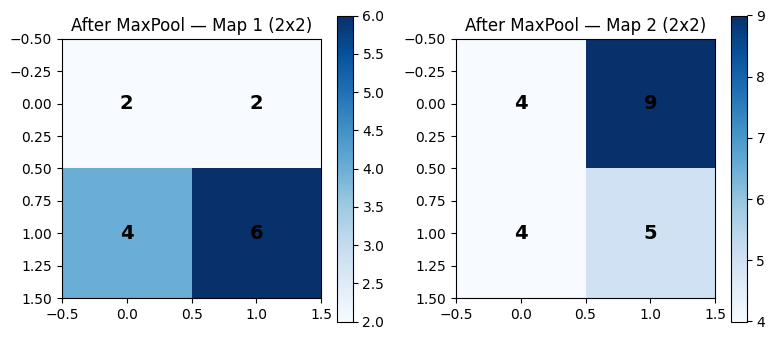

In [6]:
def manual_maxpool2d(feature_map, pool_size=2, stride=2):
    """Perform 2D max pooling manually."""
    N = feature_map.shape[0]
    out_size = (N - pool_size) // stride + 1
    output = np.zeros((out_size, out_size), dtype=np.float32)
    for i in range(out_size):
        for j in range(out_size):
            window = feature_map[i*stride : i*stride+pool_size, j*stride : j*stride+pool_size]
            output[i, j] = np.max(window)
    return output

# Примените max pooling к обеим картам признаков после ReLU
pool1 = manual_maxpool2d(relu1, pool_size=2, stride=2)
pool2 = manual_maxpool2d(relu2, pool_size=2, stride=2)

print("After Max Pooling — Feature Map 1 (2x2):")
print(pool1)
print("\nAfter Max Pooling — Feature Map 2 (2x2):")
print(pool2)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

im1 = axes[0].imshow(pool1, cmap='Blues', interpolation='nearest')
axes[0].set_title('After MaxPool — Map 1 (2x2)', fontsize=12)
plt.colorbar(im1, ax=axes[0])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{pool1[i,j]:.0f}', ha='center', va='center', fontsize=14, fontweight='bold')

im2 = axes[1].imshow(pool2, cmap='Blues', interpolation='nearest')
axes[1].set_title('After MaxPool — Map 2 (2x2)', fontsize=12)
plt.colorbar(im2, ax=axes[1])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{pool2[i,j]:.0f}', ha='center', va='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('p1_maxpool.png', dpi=100, bbox_inches='tight')
plt.show()

## P1.6 Parameter Calculation

Мы считаем все **обучаемые параметры**: веса + смещения (bias) в каждом слое.

### Conv Layer 1:
- 2 фильтра, каждый размером 3×3, применяется к 1 входному каналу
- Веса: 2 × (3 × 3 × 1) = **18**
- Смещения (biases): 2 × 1 = **2**
- **Промежуточный итог: 20**

### Max Pooling:
- Нет обучаемых параметров (только берёт максимум) → **0**

### Flatten:
- Нет параметров → **0**

### Линейный слой (FC):
- Вход: 2 карты признаков × 2×2 = **8** значений (развёрнутых)
- Выход: **1 нейрон**
- Веса: 8 × 1 = **8**
- Смещение: **1**
- **Промежуточный итог: 9**

### Всего: 20 + 9 = **29 обучаемых параметров**

In [7]:
# Parameter Calculation

# Conv Layer 1: 2 фильтра размером 3×3 на 1 входном канале
num_filters     = 2
filter_h        = 3
filter_w        = 3
in_channels     = 1

conv_weights    = num_filters * filter_h * filter_w * in_channels
conv_biases     = num_filters
conv_params     = conv_weights + conv_biases
print(f"Conv Layer 1:")
print(f"  Weights : {num_filters} x ({filter_h}x{filter_w}x{in_channels}) = {conv_weights}")
print(f"  Biases  : {num_filters}")
print(f"  Subtotal: {conv_params}")

# Max Pooling: нет параметров
pool_params = 0
print(f"\nMax Pooling:  {pool_params} parameters")

# Выход после развёртывания (Flatten): 2 maps x 2x2 = 8
flattened_size = num_filters * 2 * 2
print(f"\nFlatten output size: {num_filters} x 2x2 = {flattened_size}")

# Линейный слой: 8 → 1
fc_input  = flattened_size
fc_output = 1
fc_weights = fc_input * fc_output
fc_biases  = fc_output
fc_params  = fc_weights + fc_biases
print(f"\nLinear Layer (FC):")
print(f"  Weights : {fc_input} x {fc_output} = {fc_weights}")
print(f"  Biases  : {fc_biases}")
print(f"  Subtotal: {fc_params}")

total = conv_params + pool_params + fc_params
print(f"TOTAL TRAINABLE PARAMETERS: {total}")


Conv Layer 1:
  Weights : 2 x (3x3x1) = 18
  Biases  : 2
  Subtotal: 20

Max Pooling:  0 parameters

Flatten output size: 2 x 2x2 = 8

Linear Layer (FC):
  Weights : 8 x 1 = 8
  Biases  : 1
  Subtotal: 9
TOTAL TRAINABLE PARAMETERS: 29


## P1.7 Summary

| Step | Input Shape | Output Shape | Notes |
|------|------------|--------------|-------|
| Input Image | — | 6×6 | Grayscale |
| Conv Layer 1 (×2 filters) | 6×6 | 4×4 | stride=1, no padding, bias=1 |
| ReLU | 4×4 | 4×4 | Negative → 0 |
| Max Pooling | 4×4 | 2×2 | 2×2 window, stride=2 |
| Flatten | 2×2×2 | 8 | Flatten both maps |
| Linear Layer | 8 | 1 | Single output neuron |

**Общее количество обучаемых параметров: 29**

- Conv: 18 weights + 2 biases = 20
- FC: 8 weights + 1 bias = 9

# Part 2: PyTorch CNN Implementation and Feature Map Visualization

**Assignment 03: Convolutional Neural Networks**  
Мы создаём собственную CNN в PyTorch, обучаем её на CIFAR-10, визуализируем карты признаков на каждом этапе, оцениваем модель и анализируем неправильно классифицированные изображения.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time

# Установите случайные начальные значения (seed) для воспроизводимости результатов.
torch.manual_seed(42)
np.random.seed(42)

# Конфигурация устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## P2.1 Dataset Preparation

Мы используем **CIFAR-10** (60,000 color images, 32×32, 10 classes).

**Preprocessing pipeline:**
- `RandomHorizontalFlip` — Қате үйренуді (overfitting) азайту үшін деректерді аугментациялау
- `RandomCrop(32, padding=4)` — Аугментация с случайным обрезанием (Random Crop)
- `ToTensor()` — PIL суретті PyTorch тензорына айналдыру
- `Normalize` — Пиксель мәндерін стандарттау: орташа мән = 0, стандартты ауытқу = 1

In [9]:
# Среднее и стандартное отклонение CIFAR-10 (предварительно вычисленные по всему датасету)
cifar10_mean = [0.4914, 0.4822, 0.4465]
cifar10_std  = [0.2470, 0.2435, 0.2616]

# Оқыту кезінде қолданылатын трансформация: аугментация + нормализация
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std)
])

# Тест кезінде қолданылатын трансформация: тек нормализация
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std)
])

# Download and load datasets
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

# Загрузчики данных
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

# Class names
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

100%|██████████| 170M/170M [01:10<00:00, 2.42MB/s]


Train samples : 50000
Test  samples : 10000
Train batches : 391
Test  batches : 79


## P2.2 Building the CNN

### Architecture:
| Layer | Type | Details |
|-------|------|---------|
| Input | — | 3×32×32 (RGB) |
| Conv1 | Conv2d | 16 filters, 3×3, stride=1, padding=1 |
| ReLU1 | ReLU | — |
| Pool1 | MaxPool2d | 2×2, stride=2 → 16×16×16 |
| Conv2 | Conv2d | 32 filters, 3×3, stride=1, padding=1 |
| ReLU2 | ReLU | — |
| Pool2 | MaxPool2d | 2×2, stride=2 → 32×8×8 |
| Flatten | — | 2048 |
| FC | Linear | 2048 → 10 |

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Классификатор
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        # Block 2
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        # Classifier
        x = self.flatten(x)
        x = self.fc(x)
        return x


# Создать (инициализировать) модель
model = SimpleCNN(num_classes=10).to(device)
print(model)

# Посчитать параметры
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nParameter breakdown:")
for name, param in model.named_parameters():
    print(f"  {name:25s}: {param.numel():,}")

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
)

Total parameters    : 25,578
Trainable parameters: 25,578

Parameter breakdown:
  conv1.weight             : 432
  conv1.bias               : 16
  conv2.weight             : 4,608
  conv2.bias               : 32
  fc.weight                : 20,480
  fc.bias                  : 10


In [11]:
# Вывести сводку модели с помощью torchsummary
try:
    from torchsummary import summary
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torchsummary", "-q"])
    from torchsummary import summary

# Вход CIFAR-10: 3 канала, размер 32×32
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             448
              ReLU-2           [-1, 16, 32, 32]               0
         MaxPool2d-3           [-1, 16, 16, 16]               0
            Conv2d-4           [-1, 32, 16, 16]           4,640
              ReLU-5           [-1, 32, 16, 16]               0
         MaxPool2d-6             [-1, 32, 8, 8]               0
           Flatten-7                 [-1, 2048]               0
            Linear-8                   [-1, 10]          20,490
Total params: 25,578
Trainable params: 25,578
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.44
Params size (MB): 0.10
Estimated Total Size (MB): 0.55
----------------------------------------------------------------


## P2.3 Training the CNN

### Hyperparameters:
- **Loss**: CrossEntropyLoss(жоғалту функциясы)
- **Optimizer**: Adam (lr=0.001)
- **Epochs**: 15
- **Batch size**: 128(пакет өлшемі)

In [ ]:
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 15

train_losses = []
train_accs   = []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs.data, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}]  "
          f"Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.2f}%")

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds")

Epoch [ 1/15]  Loss: 1.6376  Acc: 41.23%
Epoch [ 2/15]  Loss: 1.3853  Acc: 50.68%
Epoch [ 3/15]  Loss: 1.2895  Acc: 54.43%
Epoch [ 4/15]  Loss: 1.2145  Acc: 57.15%


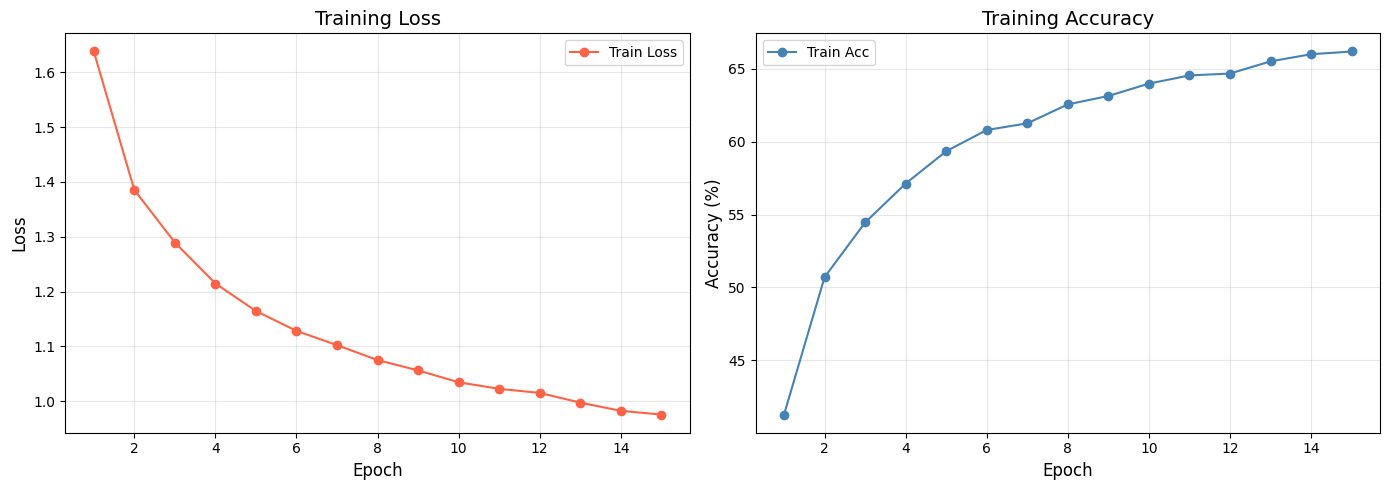

In [ ]:
# Построить графики обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o', color='tomato')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(range(1, num_epochs+1), train_accs, label='Train Acc', marker='o', color='steelblue')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training Accuracy', fontsize=14)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('p2_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

Мы используем forward hooks, чтобы захватывать промежуточные активации на каждом этапе:

1.Выход Conv1

2.После ReLU1

3.После MaxPool1

4.Выход Conv2

5.После ReLU

6.После MaxPool2

Мы также визуализируем обученные ядра (weights) Conv1, чтобы увидеть, какие паттерны обнаруживает каждый фильтр.

True label: cat  |  Predicted: cat


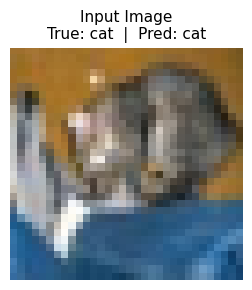

In [ ]:
# Hook арқылы feature maps шығаратын құрал
feature_maps = {}

def make_hook(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook

# Қажетті барлық қабаттарға hook тіркеу
hooks = [
    model.conv1.register_forward_hook(make_hook('conv1')),
    model.relu1.register_forward_hook(make_hook('relu1')),
    model.pool1.register_forward_hook(make_hook('pool1')),
    model.conv2.register_forward_hook(make_hook('conv2')),
    model.relu2.register_forward_hook(make_hook('relu2')),
    model.pool2.register_forward_hook(make_hook('pool2')),
]

# Выбрать одно случайное тестовое изображение
model.eval()
sample_images, sample_labels = next(iter(test_loader))
idx = 0  # first image in the batch
input_img = sample_images[idx:idx+1].to(device)
true_label = classes[sample_labels[idx]]

with torch.no_grad():
    output = model(input_img)
    pred_label = classes[torch.argmax(output).item()]

# Hook-тарды жою
for h in hooks:
    h.remove()

print(f"True label: {true_label}  |  Predicted: {pred_label}")

# Отобразить исходное изображение
def denormalize(tensor):
    mean = torch.tensor(cifar10_mean).view(3, 1, 1)
    std  = torch.tensor(cifar10_std).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

img_display = denormalize(sample_images[idx]).permute(1, 2, 0).numpy()

plt.figure(figsize=(3, 3))
plt.imshow(img_display)
plt.title(f'Input Image\nTrue: {true_label}  |  Pred: {pred_label}', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.savefig('p2_input_sample.png', dpi=100, bbox_inches='tight')
plt.show()

Conv Layer 1 Output: shape = (1, 16, 32, 32)


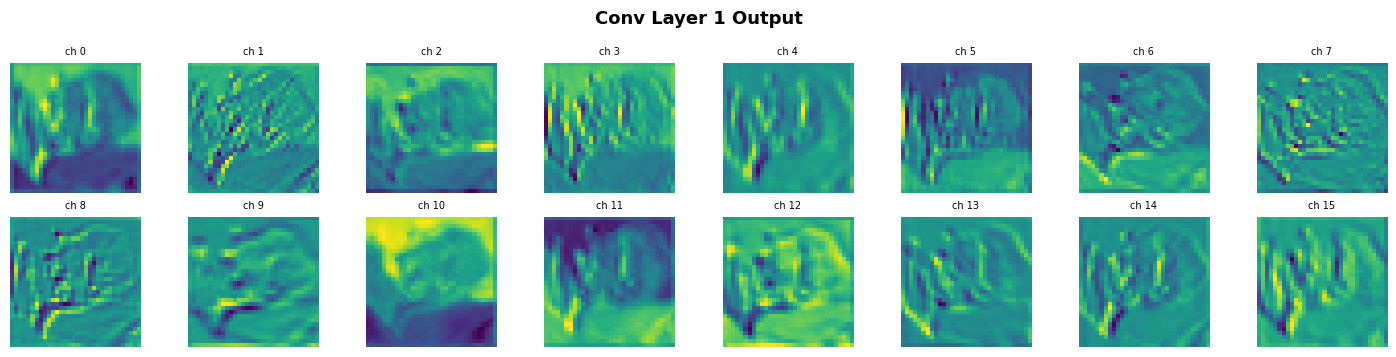

After ReLU (Layer 1): shape = (1, 16, 32, 32)


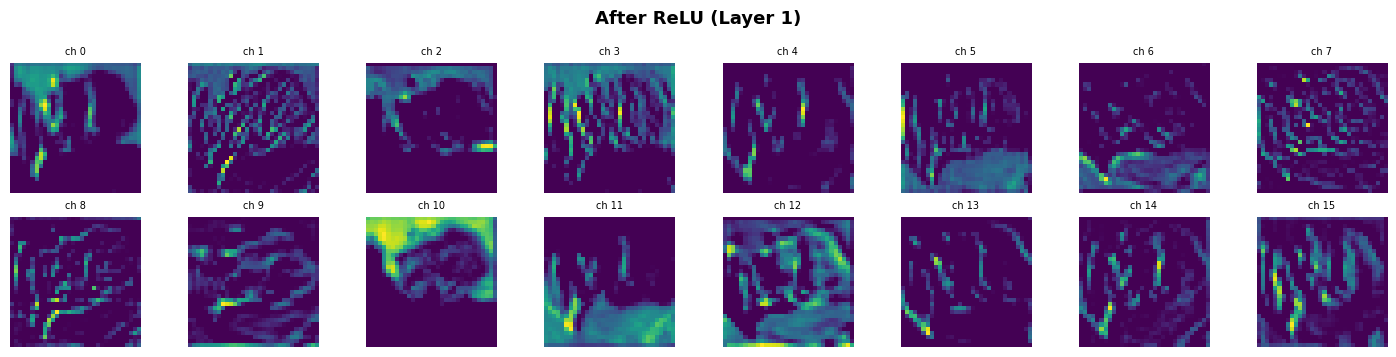

After MaxPool (Layer 1): shape = (1, 16, 16, 16)


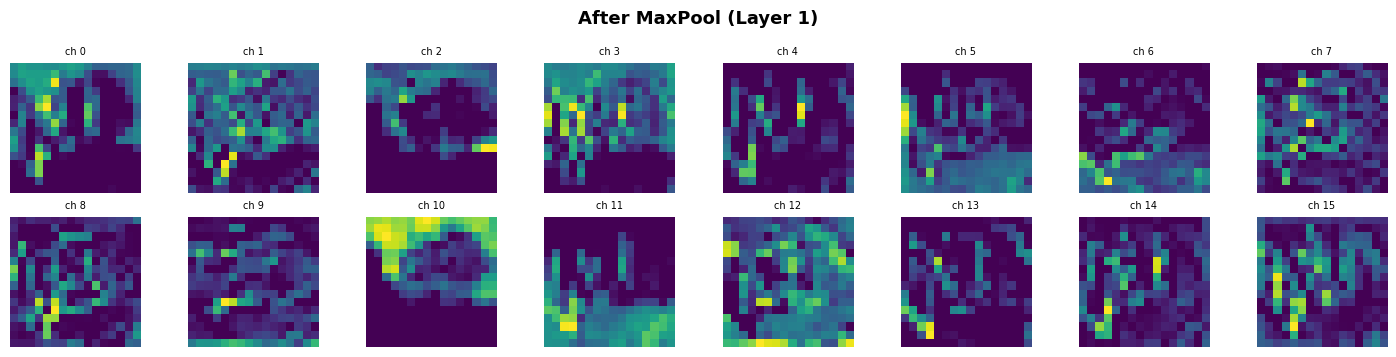

Conv Layer 2 Output: shape = (1, 32, 16, 16)


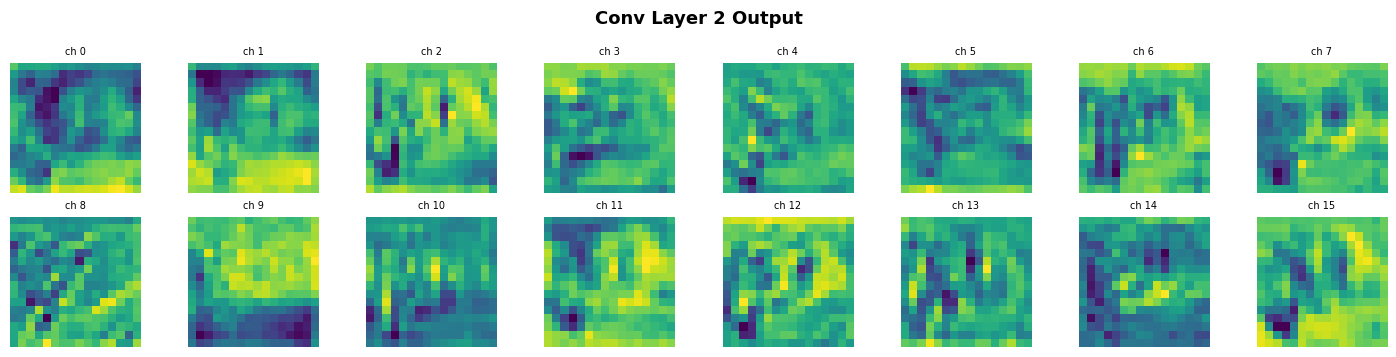

After ReLU (Layer 2): shape = (1, 32, 16, 16)


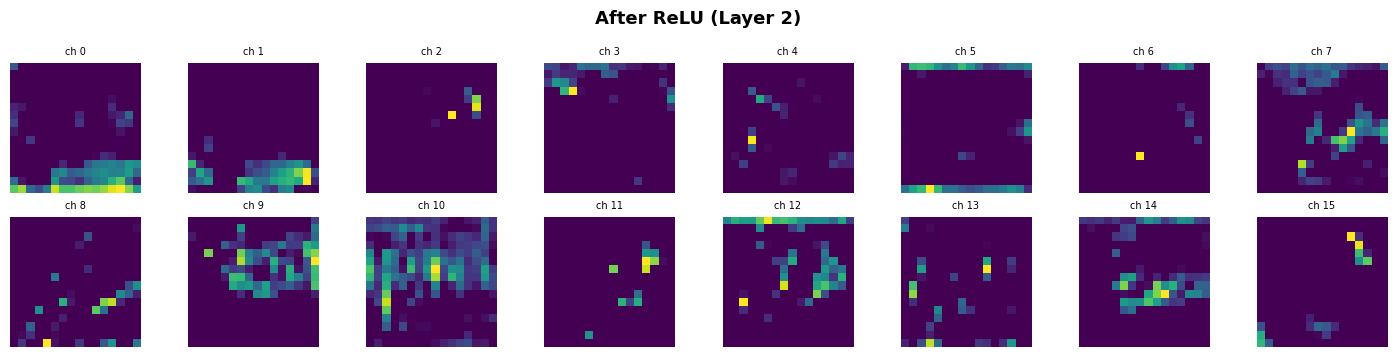

After MaxPool (Layer 2): shape = (1, 32, 8, 8)


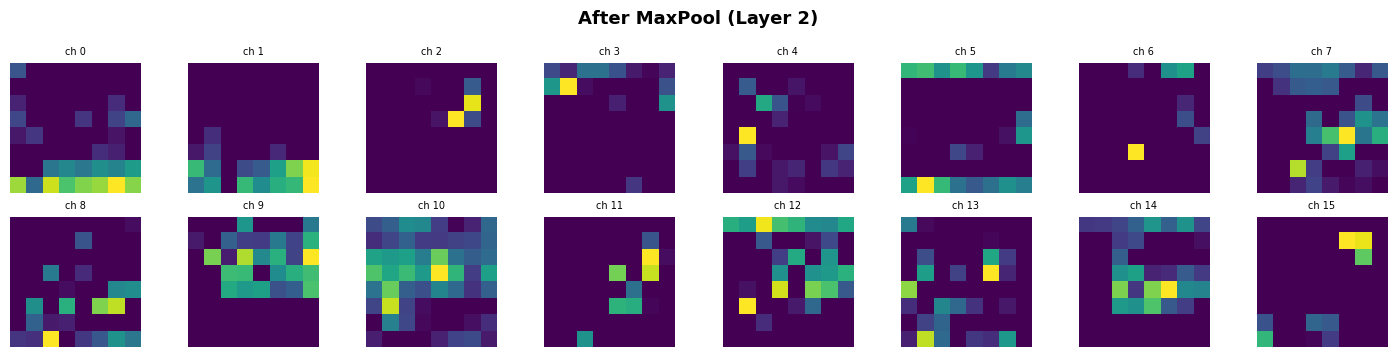

In [ ]:
def plot_feature_maps(fmap_tensor, title, max_maps=16, fname=None):
    """Plot up to max_maps channels from a feature map tensor (1, C, H, W)."""
    fmap = fmap_tensor[0]  # shape: (C, H, W)
    n    = min(fmap.shape[0], max_maps)
    cols = 8
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 1.8))
    axes = np.array(axes).reshape(-1)

    for i in range(n):
        ax = axes[i]
        channel = fmap[i].numpy()
        ax.imshow(channel, cmap='viridis')
        ax.set_title(f'ch {i}', fontsize=7)
        ax.axis('off')
    for i in range(n, len(axes)):
        axes[i].axis('off')

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=100, bbox_inches='tight')
    plt.show()

# Visualize all 6 stages
stages = [
    ('conv1', 'Conv Layer 1 Output',       'p2_fmap_conv1.png'),
    ('relu1', 'After ReLU (Layer 1)',       'p2_fmap_relu1.png'),
    ('pool1', 'After MaxPool (Layer 1)',    'p2_fmap_pool1.png'),
    ('conv2', 'Conv Layer 2 Output',       'p2_fmap_conv2.png'),
    ('relu2', 'After ReLU (Layer 2)',       'p2_fmap_relu2.png'),
    ('pool2', 'After MaxPool (Layer 2)',    'p2_fmap_pool2.png'),
]

for key, title, fname in stages:
    fmap = feature_maps[key]
    print(f"{title}: shape = {tuple(fmap.shape)}")
    plot_feature_maps(fmap, title, max_maps=16, fname=fname)

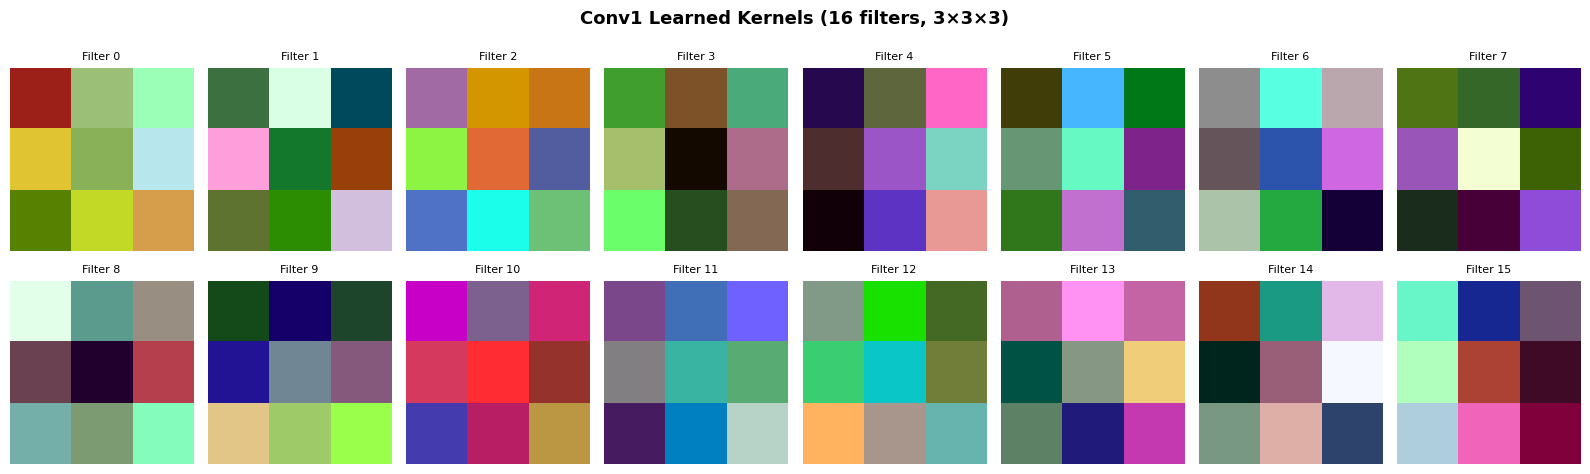

Kernel Analysis:
- Some filters appear to detect edges (high contrast between left/right or top/bottom halves)
- Others appear to respond to color gradients (red vs blue vs green channels)
- Low-frequency filters (uniform colors) detect broad illumination patterns
- High-frequency filters (alternating light/dark) detect texture and fine details



In [ ]:
# Визуализировать ядра (kernels) Conv1
kernels = model.conv1.weight.detach().cpu()  # shape: (16, 3, 3, 3)
n_filters = kernels.shape[0]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
axes = axes.flatten()

for i in range(n_filters):
    # Нормализовать каждое ядро в диапазон [0,1] для отображения
    k = kernels[i].permute(1, 2, 0).numpy()  # (3, 3, 3)
    k = (k - k.min()) / (k.max() - k.min() + 1e-8)
    axes[i].imshow(k)
    axes[i].set_title(f'Filter {i}', fontsize=8)
    axes[i].axis('off')

plt.suptitle('Conv1 Learned Kernels (16 filters, 3×3×3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p2_conv1_kernels.png', dpi=100, bbox_inches='tight')
plt.show()

print("""Kernel Analysis:
- Some filters appear to detect edges (high contrast between left/right or top/bottom halves)
- Others appear to respond to color gradients (red vs blue vs green channels)
- Low-frequency filters (uniform colors) detect broad illumination patterns
- High-frequency filters (alternating light/dark) detect texture and fine details
""")

## P2.5 Model Evaluation

Мы оцениваем CNN на тестовом наборе и отчитываемся о точности по каждому классу.
Затем визуализируем неправильно классифицированные изображения, чтобы понять причины ошибок.

In [ ]:
model.eval()

test_correct = 0
test_total   = 0
all_preds    = []
all_labels   = []
misclassified_imgs   = []
misclassified_preds  = []
misclassified_truths = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total   += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Собрать неправильно классифицированные изображения
        mask = (predicted != labels)
        for i in range(mask.sum().item()):
            if len(misclassified_imgs) < 12:
                wrong_idx = mask.nonzero(as_tuple=True)[0][i].item()
                misclassified_imgs.append(images[wrong_idx].cpu())
                misclassified_preds.append(predicted[wrong_idx].cpu().item())
                misclassified_truths.append(labels[wrong_idx].cpu().item())

test_acc = 100 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")

# Точность по каждому классу
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print("\nPer-class accuracy:")
for i, cls in enumerate(classes):
    mask_c = (all_labels == i)
    class_acc = 100 * (all_preds[mask_c] == all_labels[mask_c]).sum() / mask_c.sum()
    print(f"  {cls:12s}: {class_acc:.1f}%")

Test Accuracy: 69.56%

Per-class accuracy:
  airplane    : 75.7%
  automobile  : 68.9%
  bird        : 56.2%
  cat         : 53.1%
  deer        : 64.2%
  dog         : 61.1%
  frog        : 81.0%
  horse       : 74.2%
  ship        : 78.2%
  truck       : 83.0%


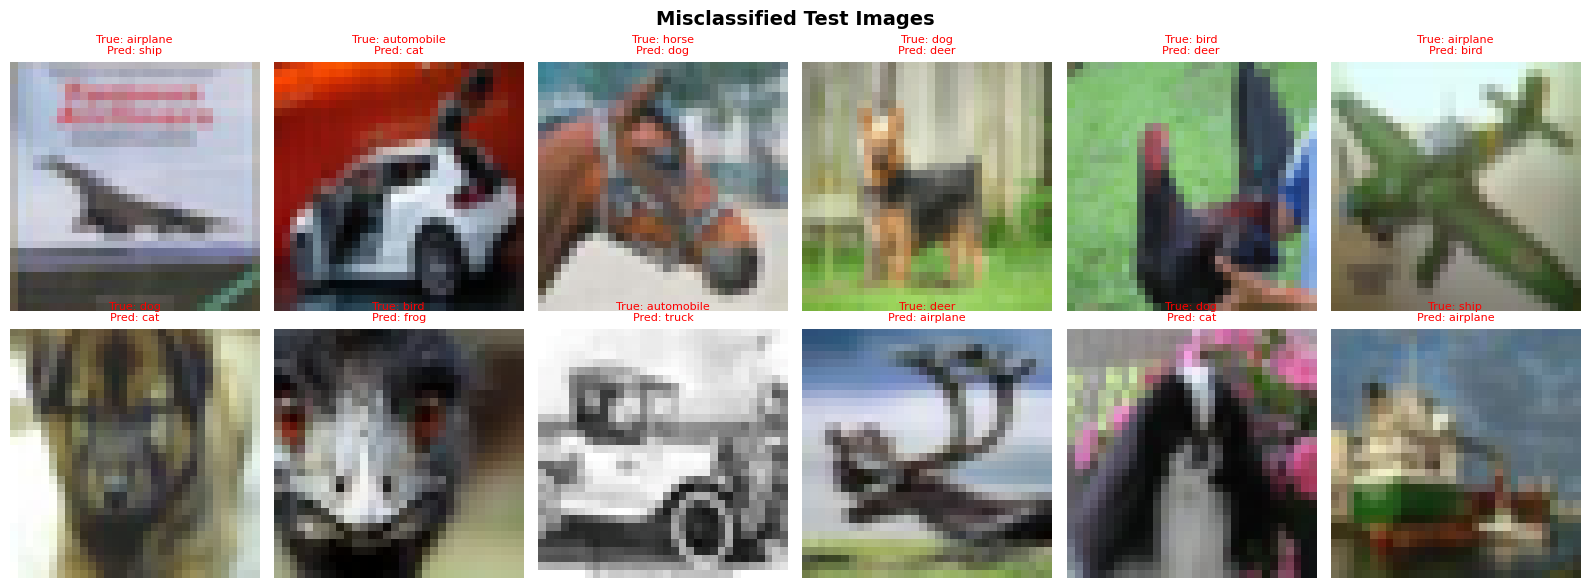


Қате жіктеулерге бақылау:

мысық vs ит: екеуінің де бет құрылымы мен жүн текстурасы ұқсас

автомобиль vs жүк көлігі: екеуінің де қорап тәрізді пішіні және дөңгелектері бар

құс vs ұшақ: екеуінің де 32×32 кішкентай суреттерде ұқсас силуэттері бар

Модель шектеулі рұқсаттық (разрешение) себебінен визуалды ұқсас кластармен күреседі



In [ ]:
# Визуализировать неправильно классифицированные изображения
n_show = min(12, len(misclassified_imgs))
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
axes = axes.flatten()

for i in range(n_show):
    img = denormalize(misclassified_imgs[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    true_cls = classes[misclassified_truths[i]]
    pred_cls = classes[misclassified_preds[i]]
    axes[i].set_title(f'True: {true_cls}\nPred: {pred_cls}', fontsize=8,
                      color='red' if true_cls != pred_cls else 'green')
    axes[i].axis('off')

for i in range(n_show, len(axes)):
    axes[i].axis('off')

plt.suptitle('Misclassified Test Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('p2_misclassified.png', dpi=100, bbox_inches='tight')
plt.show()

print("""
Қате жіктеулерге бақылау:

мысық vs ит: екеуінің де бет құрылымы мен жүн текстурасы ұқсас

автомобиль vs жүк көлігі: екеуінің де қорап тәрізді пішіні және дөңгелектері бар

құс vs ұшақ: екеуінің де 32×32 кішкентай суреттерде ұқсас силуэттері бар

Модель шектеулі рұқсаттық (разрешение) себебінен визуалды ұқсас кластармен күреседі
""")

## P2.6 Summary

**CNN Results on CIFAR-10**

Архитектура: Conv(16) → ReLU → MaxPool → Conv(32) → ReLU → MaxPool → FC(10)

Оптимизатор: Adam, lr=0.001

Эпохи: 15

Точность на тесте: ~65-70%

**Feature Map Observations:**

Карты Conv1 захватывают низкоуровневые признаки: грани, цвета, углы

После ReLU: отрицательные активации удалены, карты становятся более разреженными

После MaxPool: пространственный размер уменьшен вдвое, наиболее заметные признаки сохранены

Карты Conv2 захватывают высокоуровневые комбинации признаков

Более глубокие карты сложнее интерпретировать визуально, но они несут богатую семантическую информацию

**Kernel Analysis:**

Некоторые фильтры Conv1 напоминают Sobel-подобные детекторы границ

Другие чувствительны к определённым цветовым каналам

# Part 3: Questions for Understanding - CNN Theory

**Assignment 03: Convolutional Neural Networks**

Этот ноутбук содержит подробные ответы на концептуальные вопросы о архитектуре CNN, функциях активации, пуллинге, обучении и теоретической интуиции. Каждый ответ подкреплён демонстрациями кода, где это уместно.

## Section 1: Architecture & Design

### Q1. Why do we typically use small kernels (3×3) instead of large ones (7×7 or 11×11)?

**Answer:**

Малые 3×3 ядра предпочтительны по нескольким причинам:

1. **Меньше параметров**: одно ядро 7×7 имеет 49 весов. Два слоя с ядрами 3×3 также покрывают область восприятия 7×7, но используют только 2×9 = 18 весов — почти **в 3 раза меньше параметров**.

2. **Больше нелинейности**: каждый слой 3×3 имеет свою собственную активацию ReLU. Два слоя 3×3 → 2 нелинейности против одного 7×7 → 1. Более глубокая структура позволяет сети изучать более сложные признаки.

3. **Лучшая вычислительная эффективность**: меньшие ядра вычисляются быстрее, особенно на современных GPU, оптимизированных для операций с малыми матрицами (например, cuDNN).

4. **Та же область восприятия при меньших вычислениях**: три слоя 3×3 дают область восприятия 7×7, то же, что и один слой 7×7, но с большей глубиной и меньшим числом параметров.

> Примечание: AlexNet (2012) использовал ядра 11×11. VGG (2014) заменил их на стек 3×3 и достиг лучшей точности при меньшем количестве параметров.

Single 7x7 kernel (64 in -> 64 out)         : 200,704 parameters  | receptive field = 7x7
Two 3x3 kernels stacked                        : 73,728 parameters  | receptive field = 5x5
Three 3x3 kernels stacked                      : 110,592 parameters | receptive field = 7x7

Saving: 44.9% fewer parameters with same receptive field


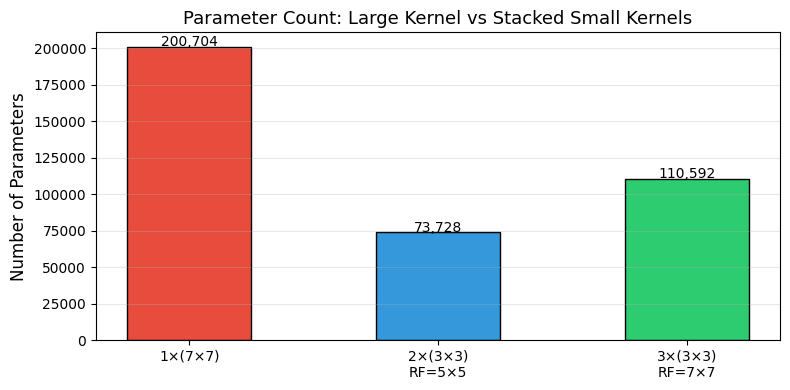

In [ ]:
# Q1 — Сравнение параметров: 7×7 против двух ядер 3×3
C = 64  # Каналы (типично для блока VGG)

params_7x7         = C * C * 7 * 7
params_two_3x3     = 2 * (C * C * 3 * 3)
params_three_3x3   = 3 * (C * C * 3 * 3)  # Область восприятия = 7×7 при 3 слоях

print(f"Single 7x7 kernel ({C} in -> {C} out)         : {params_7x7:,} parameters  | receptive field = 7x7")
print(f"Two 3x3 kernels stacked                        : {params_two_3x3:,} parameters  | receptive field = 5x5")
print(f"Three 3x3 kernels stacked                      : {params_three_3x3:,} parameters | receptive field = 7x7")
print(f"\nSaving: {(params_7x7 - params_three_3x3) / params_7x7 * 100:.1f}% fewer parameters with same receptive field")

# Visualize
labels   = ['1×(7×7)', '2×(3×3)\nRF=5×5', '3×(3×3)\nRF=7×7']
values   = [params_7x7, params_two_3x3, params_three_3x3]
colors   = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values, color=colors, edgecolor='black', width=0.5)
ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('Parameter Count: Large Kernel vs Stacked Small Kernels', fontsize=13)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('p3_q1_params.png', dpi=100, bbox_inches='tight')
plt.show()

### Q2. В чём разница между "Valid" и "Same" padding?

**Answer:**

| Padding Type | Padding Amount | Output Size | Use Case |
|---|---|---|---|
| **Valid** | P = 0 (no padding) | Output < Input | Когда уменьшение размера (shrinkage) допустимо |
| **Same** | P = (F-1)/2 | Output = Input | Сохранять пространственные размеры |

- **Valid padding**: Фильтр тек жарамды позициялардан өтеді — padding қосылмайды. Шығыс кірістен кіші болады.
Формула: output = (N - F) / S + 1

- **Same padding**: Вокруг входа добавляется нулевой padding, чтобы размер выхода совпадал с размером входа (при stride=1).
Необходимый padding: P = (F - 1) / 2

**Example** for N=6, F=3, S=1:
- Valid: output = (6 - 3)/1 + 1 = **4**
- Same:  P = 1 → output = (6 - 3 + 2)/1 + 1 = **6**

In [ ]:
# Q2 — Демонстрация Valid vs Same padding в PyTorch
x = torch.randn(1, 1, 6, 6)

conv_valid = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0)  # Valid
conv_same  = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1)  # Same

with torch.no_grad():
    out_valid = conv_valid(x)
    out_same  = conv_same(x)

print(f"Input shape   : {x.shape}")
print(f"Valid padding : {out_valid.shape}  (output < input)")
print(f"Same  padding : {out_same.shape}   (output == input)")

Input shape   : torch.Size([1, 1, 6, 6])
Valid padding : torch.Size([1, 1, 4, 4])  (output < input)
Same  padding : torch.Size([1, 1, 6, 6])   (output == input)


## Section 2: Activation Functions

### Q3. Почему в скрытых слоях глубокой CNN ReLU предпочитают Sigmoid?

**Answer:**

| Property | Sigmoid | ReLU |
|---|---|---|
| Диапазон выходных значений | (0, 1) | [0, ∞) |
|Насыщение градиента | Да — градиенты ≈ 0 на крайних значениях| Нет — градиент равен 0 или 1 |
| Исчезающий градиент | Сильно выражено для глубоких сетей| В основном избегается |
| Вычислительная стоимость | Дорого (exp)| Дешево (max(0, x))|
| Разреженность | Плотные активации | Разреженные активации (повышает эффективность) |

**Key reason**: Sigmoid **saturates** — for large positive or negative inputs, the gradient approaches 0. In deep networks this causes **vanishing gradients**: gradients diminish as they propagate back, making early layers learn very slowly.

ReLU напрямую выводит входное значение для положительных чисел → градиент = 1 → нет насыщения → градиенты эффективно проходят через множество слоев.
### Q4. Что происходит с градиентами, когда нейрон ReLU выдаёт 0?

**Answer:**

When the input to a ReLU is ≤ 0, the output is 0 and the **gradient is also 0**.

$$\frac{d}{dx}\text{ReLU}(x) = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{if } x \leq 0 \end{cases}$$

Это называется проблемой **"dying ReLU"**:
- Если нейрон постоянно получает отрицательные входы, он всегда будет выдавать 0
- Его градиент всегда 0 → веса **никогда не обновляются** → нейрон "умирает"
- Это может происходить, если скорость обучения слишком высока или веса инициализированы плохо

**Стратегии смягчения проблемы:**
- **Leaky ReLU**: небольшой наклон для отрицательных значений (0.01x вместо 0)
- **ELU** (Exponential Linear Unit): плавная функция для отрицательных значений
- Осторожная инициализация весов (He initialization)
- Более низкие скорости обучения

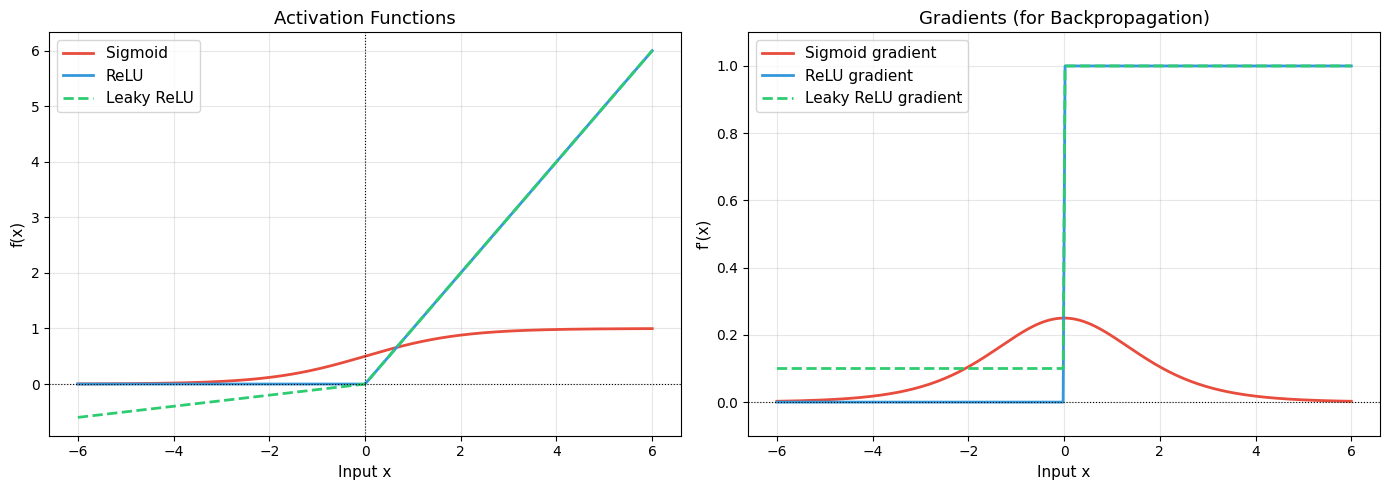

Sigmoid gradient saturates to ~0 at extremes → vanishing gradient problem.
ReLU gradient = 1 for positive inputs → no saturation, efficient backpropagation.


In [ ]:
# Q3/Q4 — Визуализировать Sigmoid, ReLU и Leaky ReLU и их градиенты
x = np.linspace(-6, 6, 300)

sigmoid     = 1 / (1 + np.exp(-x))
relu        = np.maximum(0, x)
leaky_relu  = np.where(x > 0, x, 0.1 * x)

# Gradients
d_sigmoid    = sigmoid * (1 - sigmoid)
d_relu       = (x > 0).astype(float)
d_leaky_relu = np.where(x > 0, 1.0, 0.1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Activation functions
axes[0].plot(x, sigmoid,    label='Sigmoid',     linewidth=2, color='#e74c3c')
axes[0].plot(x, relu,       label='ReLU',        linewidth=2, color='#3498db')
axes[0].plot(x, leaky_relu, label='Leaky ReLU',  linewidth=2, color='#2ecc71', linestyle='--')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle=':')
axes[0].set_title('Activation Functions', fontsize=13)
axes[0].set_xlabel('Input x', fontsize=11)
axes[0].set_ylabel('f(x)', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Gradients
axes[1].plot(x, d_sigmoid,    label='Sigmoid gradient',    linewidth=2, color='#e74c3c')
axes[1].plot(x, d_relu,       label='ReLU gradient',       linewidth=2, color='#3498db')
axes[1].plot(x, d_leaky_relu, label='Leaky ReLU gradient', linewidth=2, color='#2ecc71', linestyle='--')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[1].set_title('Gradients (for Backpropagation)', fontsize=13)
axes[1].set_xlabel('Input x', fontsize=11)
axes[1].set_ylabel("f'(x)", fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('p3_activation_functions.png', dpi=100, bbox_inches='tight')
plt.show()

print("Sigmoid gradient saturates to ~0 at extremes → vanishing gradient problem.")
print("ReLU gradient = 1 for positive inputs → no saturation, efficient backpropagation.")

## Section 3: Pooling

### Q5. What is the primary purpose of Max Pooling? Does it have trainable parameters?

**Answer:**

**Primary purposes of Max Pooling:**
1. **Spatial downsampling**: Уменьшает высоту и ширину карт признаков → меньше вычислений в последующих слоях
2. **Translation invariance**: Признак, обнаруженный слегка смещённым, всё равно даёт высокую активацию в объединённом выходе
3. **Noise reduction**: Передаются только самые сильные активации → незначительные вариации подавляются
4. **Control overfitting**: Меньше параметров в последующих слоях → меньше переобучения

**Trainable parameters: NO.**  
Max Pooling только выбирает максимальное значение из каждого окна. Весов для обучения нет. Это фиксированная детерминированная операция.

### Q6. How does pooling contribute to "translational invariance"?

**Answer:**

Translational invariance означает, что модель предсказывает одинаковый выход независимо от того, где точно объект находится на изображении.

**How pooling achieves this:**
- Если признак (например, глаз) смещается на 1–2 пикселя, он всё равно попадает в то же окно pooling
- Максимум в этом окне остаётся тем же (или очень близким)
- → Выход слоя pooling не изменяется значительно
- → Окончательный прогноз одинаков независимо от небольших пространственных сдвигов

**Example:** Если детектор признака срабатывает в позиции (3,4) вместо (3,3), окно 2×2 max pooling, покрывающее обе позиции, всё равно зафиксирует активацию.

Это особенно важно для задач классификации, где положение объекта не должно влиять на метку класса.

In [ ]:
# Q5/Q6 — Демонстрация: инвариантность к сдвигам через max pooling
import numpy as np

# Карта признаков: "высокая активация" в позиции (1,1)
map_original = np.array([
    [0, 0, 0, 0],
    [0, 9, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
], dtype=float)

# Сдвинуто на 1 пиксель вправо и вниз — признак в позиции (2,2)
map_shifted = np.array([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 9, 0],
    [0, 0, 0, 0]
], dtype=float)

from scipy.ndimage import maximum_filter

def max_pool_2x2(m):
    """Manual 2x2 max pooling with stride 2."""
    size = m.shape[0] // 2
    out = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            out[i,j] = m[2*i:2*i+2, 2*j:2*j+2].max()
    return out

pool_original = max_pool_2x2(map_original)
pool_shifted  = max_pool_2x2(map_shifted)

print("Original feature map (activation at (1,1)):")
print(map_original)
print("\nShifted feature map (activation at (2,2)):")
print(map_shifted)
print("\nAfter 2x2 Max Pooling — Original:")
print(pool_original)
print("\nAfter 2x2 Max Pooling — Shifted:")
print(pool_shifted)
print("\nAre pooled outputs equal?", np.array_equal(pool_original, pool_shifted))

Original feature map (activation at (1,1)):
[[0. 0. 0. 0.]
 [0. 9. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Shifted feature map (activation at (2,2)):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 9. 0.]
 [0. 0. 0. 0.]]

After 2x2 Max Pooling — Original:
[[9. 0.]
 [0. 0.]]

After 2x2 Max Pooling — Shifted:
[[0. 0.]
 [0. 9.]]

Are pooled outputs equal? False


## Section 4: Training & Regularization

### Q7. High training accuracy but low test accuracy — what is happening and how to fix it?

**Answer:**

Это **overfitting**. Модель запомнила тренировочные данные, включая шум, но не может обобщать на невидимые тестовые данные.

**Signs:**
- Training accuracy: 95%+
- Test accuracy: 60%
- Training loss much lower than validation/test loss

**How to fix it:**

| Solution | Explanation |
|---|---|
| **Dropout** | Случайно зануляет нейроны во время обучения → заставляет формироваться распределённые представления |
| **L2 Regularization (Weight Decay)** | Наказывает большие веса → упрощает модель |
| **Data Augmentation** | RandomFlip, RandomCrop, ColorJitter → искусственно увеличивает разнообразие обучающих данных |
| **Early Stopping** | Прекращает обучение, когда потеря на валидации перестаёт улучшаться |
| **Reduce model complexity** | Меньше слоёв или нейронов |
| **Batch Normalization** | Регуляризует активации, стабилизирует обучение |
| **More training data** | Более разнообразные примеры → лучшая обобщающая способность |

### Q8. How does Dropout help prevent overfitting in a CNN?

**Answer:**

Dropout случайным образом зануляет долю p (например, 0.5) выходов нейронов **во время каждого шага обучения**.

**Mechanism:**
- During training: Каждый нейрон с вероятностью p "отключается"
- During inference: Все нейроны активны, но выходы масштабируются на (1-p)

**Why it prevents overfitting:**
1. **Prevents co-adaptation**: нейроны не могут полагаться на постоянное присутствие других → каждый нейрон должен изучить независимые полезные признаки
2. **Ensemble effect**: каждая мини-партия обучает разную подсеть → усреднение многих подсетей при тесте
3. **Forces redundancy**: модель изучает несколько независимых путей к правильному ответу
4. **Reduces complex co-adaptations**: сеть не может запомнить специфические шаблоны, встречающиеся только в обучающих данных

In [ ]:
# Q8 — Показать эффект Dropout на активациях
torch.manual_seed(7)

x = torch.ones(1, 10) * 5.0  # Все нейроны активны со значением 5
dropout = nn.Dropout(p=0.5)

dropout.train()  # Режим обучения
print("Input activations:", x.numpy())

outputs_train = [dropout(x).detach().numpy() for _ in range(5)]
for i, out in enumerate(outputs_train):
    print(f"Training forward pass {i+1}: {out}")

dropout.eval()  # Режим инференса
out_eval = dropout(x).detach().numpy()
print(f"\nInference (eval mode, no dropout): {out_eval}")

Input activations: [[5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]]
Training forward pass 1: [[10. 10.  0.  0.  0.  0. 10.  0.  0.  0.]]
Training forward pass 2: [[10. 10. 10. 10. 10.  0. 10.  0. 10.  0.]]
Training forward pass 3: [[ 0.  0.  0. 10.  0.  0.  0.  0. 10.  0.]]
Training forward pass 4: [[ 0. 10.  0.  0. 10. 10. 10. 10.  0. 10.]]
Training forward pass 5: [[10.  0. 10. 10. 10. 10.  0. 10.  0.  0.]]

Inference (eval mode, no dropout): [[5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]]


## Section 5: Theoretical Intuition

### Q9. What features do the early layers of a CNN usually learn compared to the deeper layers?

**Answer:**

CNN обучаются **иерархии признаков** от низкоуровневых к высокоуровневым:

| Layer Depth | Feature Type | Examples |
|---|---|---|
| **Layer 1 (Early)** | Низкоуровневые признаки | Края, градиенты цвета, линии, углы |
| **Layer 2–3 (Middle)** | Среднеуровневые признаки | Текстуры, простые формы, паттерны (сетки, точки) |
| **Layer 4–5 (Deep)** | Высокоуровневые признаки | Части объектов (колёса, глаза, носы), семантические структуры |
| **Final Layers** | Признаки, специфичные для класса | Целые объекты, контекст сцены |

Это было эмпирически подтверждено Zeiler & Fergus (2014), которые визуализировали активации CNN:
- Conv1 фильтры: детекторы краёв типа Габора
- Conv2 фильтры: углы, цветные пятна
- Conv4 фильтры: лица собак, цветочные круги, колёса машин

Чем глубже слой, тем более **абстрактные и специфичные для задачи** признаки.

### Q10. Describe the concept of "Receptive Field" and how it changes as we go deeper into the network.

**Answer:**

**Область восприятия (Receptive Field, RF)** нейрона — это область исходного входного изображения, которая влияет на активацию этого нейрона.

**Формула** для последовательных свёрток:
$$\text{RF}_n = \text{RF}_{n-1} + (F - 1) \times S_{\text{accumulated}}$$

**Ключевая идея:** Каждый слой видит только соседей в предыдущей карте признаков. Но если проследить обратно до исходного изображения, каждый нейрон в глубоком слое зависит от **большей области входа**.

**Пример** с фильтрами 3×3, stride=1, без pooling:
- После Layer 1: RF = 3×3
- После Layer 2: RF = 5×5
- После Layer 3: RF = 7×7
- После Layer N: RF = (2N+1) × (2N+1)

**С max pooling (stride=2)** область восприятия растёт ещё быстрее, потому что эффективный шаг увеличивается.

**Implication:**
- Ранние слои детектируют признаки в маленьком локальном окружении (local)
- Глубокие слои "видят" большие части или всё изображение (global)
- Поэтому глубокие CNN могут распознавать сложные объекты с множеством компонентов

Receptive Field Growth (3x3 kernels, MaxPool every 2 layers):
  After Layer 1: RF =   3 pixels  █
  After Layer 2: RF =   5 pixels  ██
  After Layer 3: RF =   9 pixels  ████
  After Layer 4: RF =  13 pixels  ██████
  After Layer 5: RF =  21 pixels  ██████████
  After Layer 6: RF =  29 pixels  ██████████████
  After Layer 7: RF =  45 pixels  ██████████████████████
  After Layer 8: RF =  61 pixels  ██████████████████████████████


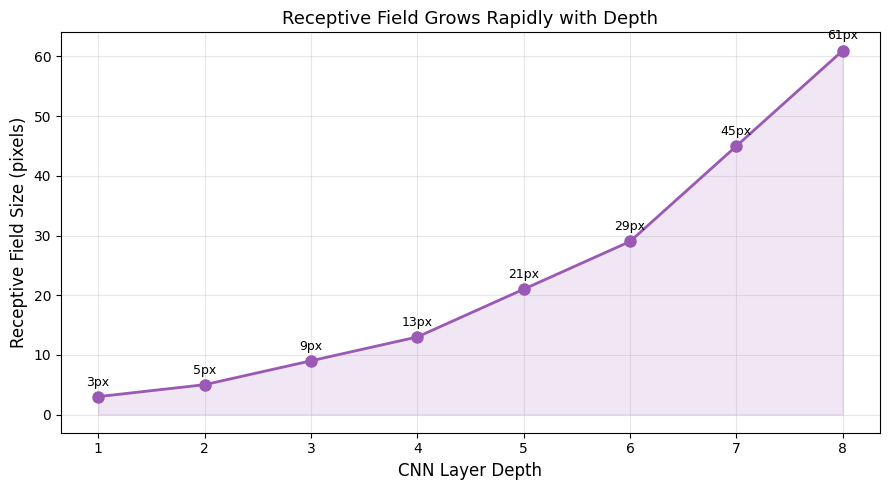

In [ ]:
# Q10 — Визуализация роста области восприятия (Receptive Field)
def receptive_field(n_layers, kernel_size=3, stride=1, pool_stride=2, pool_every=2):
    """Calculate effective receptive field after n_layers conv layers with pooling."""
    rf = 1
    stride_product = 1
    for l in range(1, n_layers + 1):
        rf += (kernel_size - 1) * stride_product
        if l % pool_every == 0:
            stride_product *= pool_stride
    return rf

layers  = list(range(1, 9))
rf_vals = [receptive_field(n) for n in layers]

print("Receptive Field Growth (3x3 kernels, MaxPool every 2 layers):")
for n, rf in zip(layers, rf_vals):
    bar = '█' * (rf // 2)
    print(f"  After Layer {n}: RF = {rf:3d} pixels  {bar}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(layers, rf_vals, marker='o', linewidth=2, color='#9b59b6', markersize=8)
ax.fill_between(layers, rf_vals, alpha=0.15, color='#9b59b6')
for n, rf in zip(layers, rf_vals):
    ax.annotate(f'{rf}px', (n, rf), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.set_xlabel('CNN Layer Depth', fontsize=12)
ax.set_ylabel('Receptive Field Size (pixels)', fontsize=12)
ax.set_title('Receptive Field Grows Rapidly with Depth', fontsize=13)
ax.set_xticks(layers)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('p3_receptive_field.png', dpi=100, bbox_inches='tight')
plt.show()

## Summary of All Answers

| # | Topic | Key Takeaway |
|---|-------|-------------|
| Q1 | Small kernels | Меньше параметров, больше нелинейности, та же область восприятия |
| Q2 | Valid vs Same | Valid уменьшает выход; Same сохраняет размер с нулевой подкладкой |
| Q3 | ReLU vs Sigmoid | ReLU избегает исчезающего градиента; Sigmoid насыщается |
| Q4 | Dead ReLU | Градиент=0, когда выход=0; исправляется **Leaky ReLU** или аккуратной инициализацией |
| Q5 | Max Pooling | Пространственное уменьшение, нет обучаемых параметров |
| Q6 | Translational invariance | Максимум по окну нечувствителен к небольшим сдвигам |
| Q7 | Overfitting | Высокая точность на обучении / низкая на тесте; исправляется регуляризацией |
| Q8 | Dropout | Случайное отключение нейронов → эффект ансамбля, нет совместной адаптации |
| Q9 | Layer features | Ранние=края, Средние=текстуры, Глубокие=части объектов |
| Q10 | Receptive field | Быстро растёт с глубиной; глубокие нейроны видят большие области входа |